In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [17]:
a = pd.read_csv('../runs/pitch_eval/streaming_compare_20260530_165807/f0_compare.csv')

In [29]:
cols = []
for col in a.columns:
    if 'f0' in col:
        cols.append(col)
a[cols]

,offline_f0,zeros_m1.0_f0,zeros_m0.5_f0,zeros_m0.0_f0,refill_m1.0_f0,refill_m0.5_f0,refill_m0.0_f0
0,685.159,672.075,109.585,237.075,672.075,109.585,237.075
1,152.594,224.277,128.894,237.075,224.277,128.894,237.075
2,149.734,256.640,136.972,237.075,256.640,136.973,237.075
3,152.163,251.744,243.329,44.787,251.744,243.341,44.787
4,152.597,149.664,256.118,46.574,149.666,256.208,46.574
...,...,...,...,...,...,...,...
6575,469.724,466.317,242.233,467.988,475.226,242.233,467.988
6576,242.230,242.246,242.233,242.233,246.941,242.233,242.233
6577,242.233,242.233,242.233,242.233,246.942,242.233,242.233
6578,242.232,242.232,473.085,242.233,246.942,473.108,242.233


In [39]:
a

,time_s,offline_f0,offline_conf,zeros_m1.0_f0,zeros_m1.0_conf,zeros_m0.5_f0,zeros_m0.5_conf,zeros_m0.0_f0,zeros_m0.0_conf,refill_m1.0_f0,refill_m1.0_conf,refill_m0.5_f0,refill_m0.5_conf,refill_m0.0_f0,refill_m0.0_conf
0,0.00,685.159,0.0629,672.075,0.0042,109.585,0.1089,237.075,0.1090,672.075,0.0042,109.585,0.1089,237.075,0.1090
1,0.01,152.594,0.0524,224.277,0.0173,128.894,0.1084,237.075,0.1090,224.277,0.0173,128.894,0.1084,237.075,0.1090
2,0.02,149.734,0.0633,256.640,0.0415,136.972,0.1065,237.075,0.1090,256.640,0.0416,136.973,0.1065,237.075,0.1090
3,0.03,152.163,0.0775,251.744,0.0581,243.329,0.0869,44.787,0.1090,251.744,0.0581,243.341,0.0869,44.787,0.1090
4,0.04,152.597,0.0858,149.664,0.0629,256.118,0.0288,46.574,0.1089,149.666,0.0631,256.208,0.0290,46.574,0.1089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6575,65.75,469.724,0.0722,466.317,0.0546,242.233,0.0641,467.988,0.0638,475.226,0.0554,242.233,0.0643,467.988,0.0638
6576,65.76,242.230,0.0734,242.246,0.0642,242.233,0.0673,242.233,0.0568,246.941,0.0675,242.233,0.0673,242.233,0.0568
6577,65.77,242.233,0.0747,242.233,0.0606,242.233,0.0766,242.233,0.0523,246.942,0.0653,242.233,0.0767,242.233,0.0523
6578,65.78,242.232,0.0751,242.232,0.0600,473.085,0.0749,242.233,0.0507,246.942,0.0646,473.108,0.0749,242.233,0.0507


In [73]:
mean

np.float64(154.1020696945967)

Уверенных 0.8060790273556231
Попаданий 0.9775641025641025


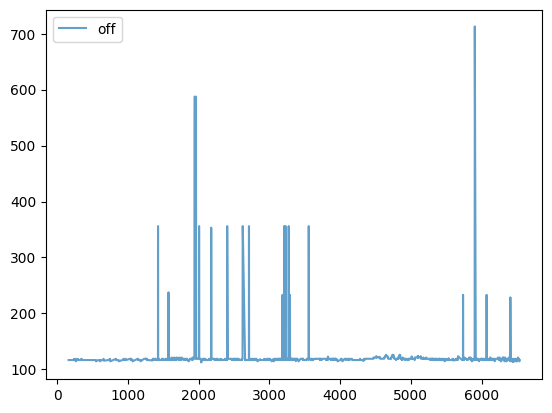

In [86]:
name = 'refill_m0.0'
# name = 'offline'
d = a[a[f'{name}_conf'] >= 0.7]
plt.plot(d[f'{name}_f0'], alpha=0.7)
print("Уверенных",len(d)/len(a))
# mean = d[f'{name}_f0'].mean()
mean = 116
ideal = 116.54
print('Попаданий',len(d[(d[f'{name}_f0'] <= 126) & (d[f'{name}_f0'] >= 116)])/len(d))
# plt.plot(d['refill_m0.0_f0'], alpha=0.7)
plt.legend(['off','z_1'])

<Axes: >

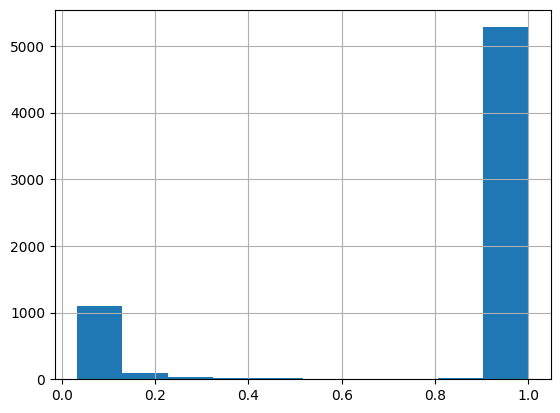

In [81]:
a[f'{name}_conf'].hist()

In [9]:
root = '../runs/pitch_eval/20260513_215529/A#2_260429_1923/'
for note in os.listdir(root):
    if os.path.isdir(os.path.join(root, note)):
        a = pd.read_csv(os.path.join(root, note, 'f0_curves.csv'))
        b = a[(a['detector']=='pesto') & (a['f0_hz'] > 1)]
        print(note)
        med = np.median(b['f0_hz'])
        print(((b['f0_hz'] > med*1.05) | (b['f0_hz'] < med*0.95)).mean())
        print('---')

In [12]:
b = pd.read_csv('../runs/pitch_eval/20260513_215529/A#2_260429_1923/f0_curves.csv')

In [13]:
b

,time_s,detector,f0_hz,confidence,signal_active
0,0.000000,yin,1005.5541,1.0000,0
1,0.023220,yin,0.0000,0.0000,0
2,0.046440,yin,0.0000,0.0000,0
3,0.069660,yin,0.0000,0.0000,0
4,0.092880,yin,0.0000,0.0000,0
...,...,...,...,...,...
9410,65.760002,pesto,0.0000,0.0735,0
9411,65.769997,pesto,0.0000,0.0747,0
9412,65.779999,pesto,0.0000,0.0750,0
9413,65.790001,pesto,0.0000,0.0645,0


In [14]:
c = b[(b['detector']=='pesto') & (b['f0_hz'] > 1)]
# plt.plot(c
# print(((c['f0_hz'] > 200) | (c['f0_hz'] < 170)).mean())

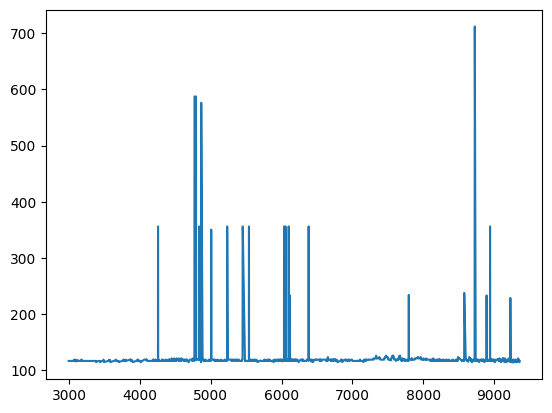

In [16]:
plt.plot(c['f0_hz'])

In [1]:
#!/usr/bin/env python3
"""Small playground for PESTO-style self-supervised losses.

Run from repo root:
    source venv/bin/activate
    python loss_playground.py
    python loss_playground.py --bins 219 --shift 8 --sharpness 3 12 40

What this shows:
- pesto CE: what pesto-full uses: torch.nn.CrossEntropyLoss(input, target),
  where input is already a softmax probability vector from the encoder.
- prob CE: textbook cross entropy between probability distributions:
  -sum(target * log(input)).

The current fine-tune code vendors the same loss semantics as pesto-full.
"""
from __future__ import annotations

import argparse
import math
from dataclasses import dataclass

import torch
import torch.nn.functional as F


EPS = torch.finfo(torch.float32).eps


def gaussian_probs(bins: int, center: float, sharpness: float) -> torch.Tensor:
    """Return a normalized bell-shaped distribution over pitch bins."""
    x = torch.arange(bins, dtype=torch.float32)
    logits = -0.5 * ((x - center) / sharpness) ** 2
    return torch.softmax(logits, dim=-1)


def one_hot(bins: int, index: int) -> torch.Tensor:
    out = torch.zeros(bins, dtype=torch.float32)
    out[index] = 1.0
    return out


def shift_distribution(probs: torch.Tensor, shift: int) -> torch.Tensor:
    """Shift without wrap; mass shifted outside the range is dropped."""
    out = torch.zeros_like(probs)
    if shift >= 0:
        out[shift:] = probs[:-shift] if shift else probs
    else:
        out[:shift] = probs[-shift:]
    total = out.sum()
    return out / total.clamp_min(EPS)


def pesto_ce(input_probs: torch.Tensor, target_probs: torch.Tensor) -> torch.Tensor:
    """PESTO/upstream-style CE: CrossEntropyLoss receives probabilities as input."""
    return F.cross_entropy(input_probs.unsqueeze(0), target_probs.unsqueeze(0))


def pesto_symmetric_ce(input_probs: torch.Tensor, target_probs: torch.Tensor) -> torch.Tensor:
    return 0.5 * (pesto_ce(input_probs, target_probs) + pesto_ce(target_probs, input_probs))


def prob_ce(input_probs: torch.Tensor, target_probs: torch.Tensor) -> torch.Tensor:
    """Textbook CE H(target, input) for probability distributions."""
    return -(target_probs * input_probs.clamp_min(EPS).log()).sum()


def prob_symmetric_ce(input_probs: torch.Tensor, target_probs: torch.Tensor) -> torch.Tensor:
    return 0.5 * (prob_ce(input_probs, target_probs) + prob_ce(target_probs, input_probs))


def entropy(probs: torch.Tensor) -> torch.Tensor:
    return prob_ce(probs, probs)


def shift_cross_entropy_pesto(x1: torch.Tensor, x2: torch.Tensor, shift: int, pad_length: int) -> torch.Tensor:
    """Same mechanics as ml.finetune_pesto.vendor.losses.ShiftCrossEntropy."""
    x1_batch = x1.unsqueeze(0)
    x2_batch = x2.unsqueeze(0)
    target = torch.tensor([shift], dtype=torch.long)

    x1_padded = F.pad(x1_batch, (pad_length, pad_length))
    x2_padded = F.pad(x2_batch, (2 * pad_length, 2 * pad_length))
    idx = target.unsqueeze(1) + torch.arange(x1_padded.size(-1)) + pad_length
    shifted_x2 = torch.gather(x2_padded, dim=1, index=idx)
    return F.cross_entropy(x1_padded, shifted_x2)


def shift_cross_entropy_prob(x1: torch.Tensor, x2: torch.Tensor, shift: int, pad_length: int) -> torch.Tensor:
    """Probability-CE variant with the same padding/gather mechanics."""
    x1_batch = x1.unsqueeze(0)
    x2_batch = x2.unsqueeze(0)
    target = torch.tensor([shift], dtype=torch.long)

    x1_padded = F.pad(x1_batch, (pad_length, pad_length))
    x2_padded = F.pad(x2_batch, (2 * pad_length, 2 * pad_length))
    idx = target.unsqueeze(1) + torch.arange(x1_padded.size(-1)) + pad_length
    shifted_x2 = torch.gather(x2_padded, dim=1, index=idx)
    return prob_ce(x1_padded.squeeze(0), shifted_x2.squeeze(0))


In [24]:
@dataclass(frozen=True)
class Pair:
    name: str
    input_probs: torch.Tensor
    target_probs: torch.Tensor


def describe(name: str, probs: torch.Tensor) -> None:
    topv, topi = torch.topk(probs, k=min(5, probs.numel()))
    top = ", ".join(f"{int(i)}:{float(v):.4f}" for v, i in zip(topv, topi))
    print(f"{name:>20}: sum={float(probs.sum()):.6f} entropy={float(entropy(probs)):.6f} top=[{top}]")


def report_pair(pair: Pair) -> None:
    print(f"\n== {pair.name} ==")
    describe("input", pair.input_probs)
    describe("target", pair.target_probs)
    print(f"pesto CE          : {float(pesto_ce(pair.input_probs, pair.target_probs)):.6f}")
    print(f"pesto symmetric CE: {float(pesto_symmetric_ce(pair.input_probs, pair.target_probs)):.6f}")
    print(f"prob CE           : {float(prob_ce(pair.input_probs, pair.target_probs)):.6f}")
    print(f"prob symmetric CE : {float(prob_symmetric_ce(pair.input_probs, pair.target_probs)):.6f}")


In [ ]:
def main() -> int:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--bins", type=int, default=219)
    parser.add_argument("--center", type=int, default=96)
    parser.add_argument("--shift", type=int, default=8)
    parser.add_argument("--pad-length", type=int, default=16)
    parser.add_argument("--sharpness", type=float, nargs="+", default=[3.0, 12.0, 40.0])
    args = parser.parse_args()

    bins = args.bins
    center = min(max(args.center, 0), bins - 1)
    shifted_center = min(max(center + args.shift, 0), bins - 1)

    print(f"bins={bins} log(bins)={math.log(bins):.6f} center={center} shift={args.shift}")
    print("Note: PESTO CE uses CrossEntropyLoss on already-softmaxed encoder outputs.")

    uniform = torch.full((bins,), 1.0 / bins)
    peak = one_hot(bins, center)
    shifted_peak = one_hot(bins, shifted_center)

    pairs = [
        Pair("uniform vs uniform", uniform, uniform),
        Pair("onehot match", peak, peak),
        Pair("onehot mismatch", peak, shifted_peak),
    ]

    for sharpness in args.sharpness:
        a = gaussian_probs(bins, center, sharpness)
        b = gaussian_probs(bins, center + 0.4, sharpness)
        c = gaussian_probs(bins, shifted_center, sharpness)
        pairs.extend([
            Pair(f"gauss s={sharpness:g} near", a, b),
            Pair(f"gauss s={sharpness:g} shifted", a, c),
        ])

    for pair in pairs:
        report_pair(pair)

    source = gaussian_probs(bins, center, args.sharpness[0])
    shifted = shift_distribution(source, args.shift)
    print("\n== ShiftCrossEntropy mechanics ==")
    describe("x1", source)
    describe("x2 shifted", shifted)
    print(f"pesto SCE aligned : {float(shift_cross_entropy_pesto(source, shifted, args.shift, args.pad_length)):.6f}")
    print(f"prob SCE aligned  : {float(shift_cross_entropy_prob(source, shifted, args.shift, args.pad_length)):.6f}")
    print(f"pesto SCE wrong   : {float(shift_cross_entropy_pesto(source, shifted, 0, args.pad_length)):.6f}")
    print(f"prob SCE wrong    : {float(shift_cross_entropy_prob(source, shifted, 0, args.pad_length)):.6f}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


In [14]:
bins=219
center = 96
shift=8
shifted_center = min(max(center + shift, 0), bins - 1)

pad_length=16
sharpness=[3,13,40][0]

In [15]:
uniform = torch.full((bins,), 1.0 / bins)
peak = one_hot(bins, center)
shifted_peak = one_hot(bins, shifted_center)

In [16]:
a = gaussian_probs(bins, center, sharpness)
b = gaussian_probs(bins, center + 0.4, sharpness)
c = gaussian_probs(bins, shifted_center, sharpness)

In [37]:
pair = Pair(f"gauss s={sharpness:g} near", a, c)
report_pair(pair)


== gauss s=3 near ==
               input: sum=1.000000 entropy=2.517550 top=[96:0.1330, 97:0.1258, 95:0.1258, 98:0.1065, 94:0.1065]
              target: sum=1.000000 entropy=2.517550 top=[104:0.1330, 103:0.1258, 105:0.1258, 102:0.1065, 106:0.1065]
pesto CE          : 5.377956
pesto symmetric CE: 5.377956
prob CE           : 6.065222
prob symmetric CE : 6.065222


In [34]:
pair = Pair(f"gauss s={sharpness:g} near", a, a)
report_pair(pair)


== gauss s=3 near ==
               input: sum=1.000000 entropy=2.517550 top=[96:0.1330, 97:0.1258, 95:0.1258, 98:0.1065, 94:0.1065]
              target: sum=1.000000 entropy=2.517550 top=[96:0.1330, 97:0.1258, 95:0.1258, 98:0.1065, 94:0.1065]
pesto CE          : 5.299817
pesto symmetric CE: 5.299817
prob CE           : 2.517550
prob symmetric CE : 2.517550


In [ ]:
F.cross_entropy(input_probs.unsqueeze(0), target_probs.unsqueeze(0))

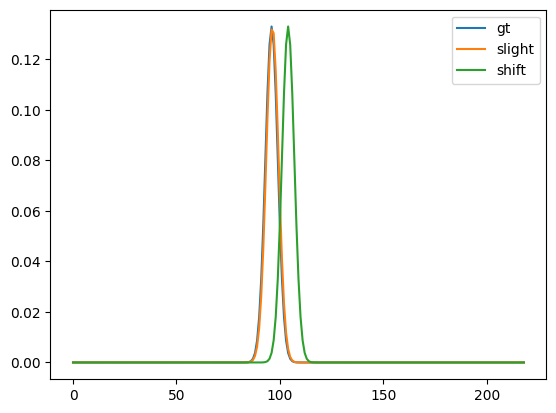

In [29]:
plt.plot(a)
plt.plot(b)
plt.plot(c)
plt.legend(['gt', 'slight','shift'])